In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/staging/stg_walmart_demand.csv")

df.head()

,store_id,department_id,date,weekly_sales_amount,isholiday,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,store_type,store_size,sku_id,location_id,demand_units
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315,SKU_001,STORE_001,249
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315,SKU_001,STORE_001,460
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315,SKU_001,STORE_001,416
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315,SKU_001,STORE_001,194
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315,SKU_001,STORE_001,218


In [2]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   store_id             421570 non-null  int64  
 1   department_id        421570 non-null  int64  
 2   date                 421570 non-null  str    
 3   weekly_sales_amount  421570 non-null  float64
 4   isholiday            421570 non-null  bool   
 5   temperature          421570 non-null  float64
 6   fuel_price           421570 non-null  float64
 7   markdown1            150681 non-null  float64
 8   markdown2            111248 non-null  float64
 9   markdown3            137091 non-null  float64
 10  markdown4            134967 non-null  float64
 11  markdown5            151432 non-null  float64
 12  cpi                  421570 non-null  float64
 13  unemployment         421570 non-null  float64
 14  store_type           421570 non-null  str    
 15  store_size           421570 

store_id                    0
department_id               0
date                        0
weekly_sales_amount         0
isholiday                   0
temperature                 0
fuel_price                  0
markdown1              270889
markdown2              310322
markdown3              284479
markdown4              286603
markdown5              270138
cpi                         0
unemployment                0
store_type                  0
store_size                  0
sku_id                      0
location_id                 0
demand_units                0
dtype: int64

In [3]:
sku_variability = df.groupby("sku_id")["demand_units"].agg(
    ["mean", "std"]
)

sku_variability["cv"] = (
    sku_variability["std"] / sku_variability["mean"]
)

sku_variability.sort_values("cv", ascending=False).head(20)

,mean,std,cv
sku_id,,,
SKU_078,0.004255,0.065233,15.329710
SKU_045,0.115702,0.341817,2.954272
SKU_059,6.933999,19.917251,2.872404
SKU_099,4.105568,11.028492,2.686228
SKU_051,0.136298,0.363543,2.667254
SKU_047,0.705882,1.546247,2.190517
SKU_018,73.361503,138.382889,1.886315
SKU_056,38.332766,59.792319,1.559823
SKU_054,1.036920,1.500839,1.447400


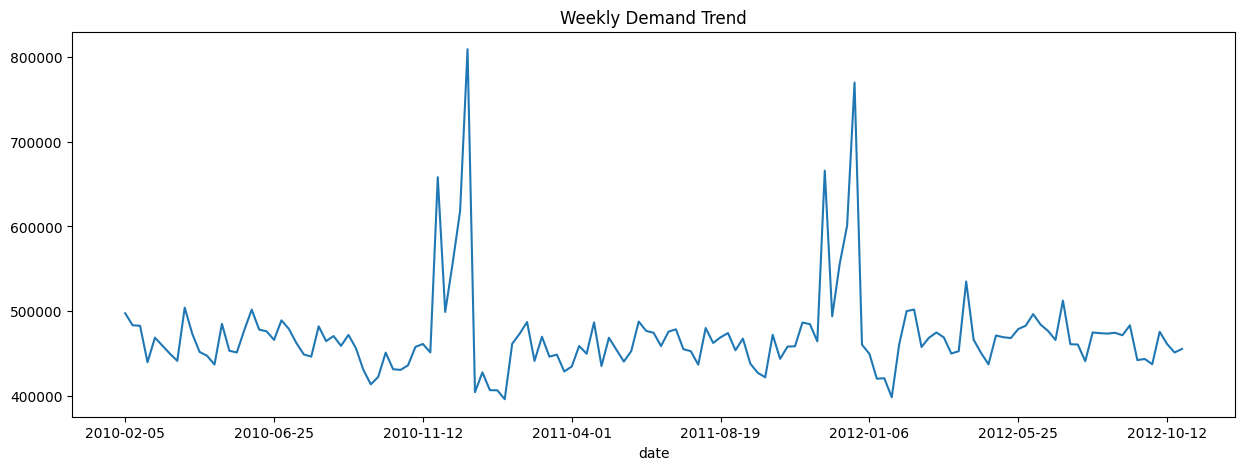

In [4]:
weekly_demand = df.groupby("date")["demand_units"].sum()

weekly_demand.plot(figsize=(15,5))
plt.title("Weekly Demand Trend")
plt.show()

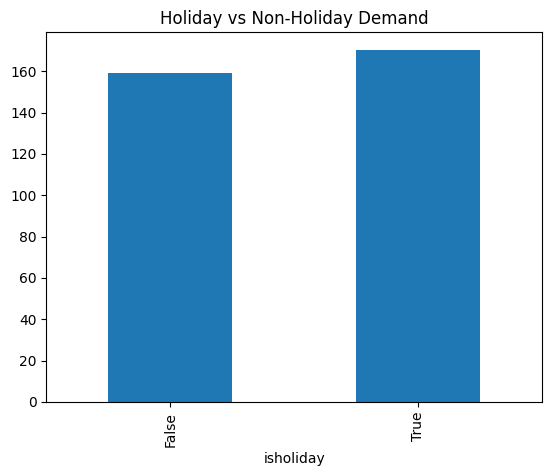

In [5]:
holiday_sales = df.groupby("isholiday")["demand_units"].mean()

holiday_sales.plot(kind="bar")
plt.title("Holiday vs Non-Holiday Demand")
plt.show()

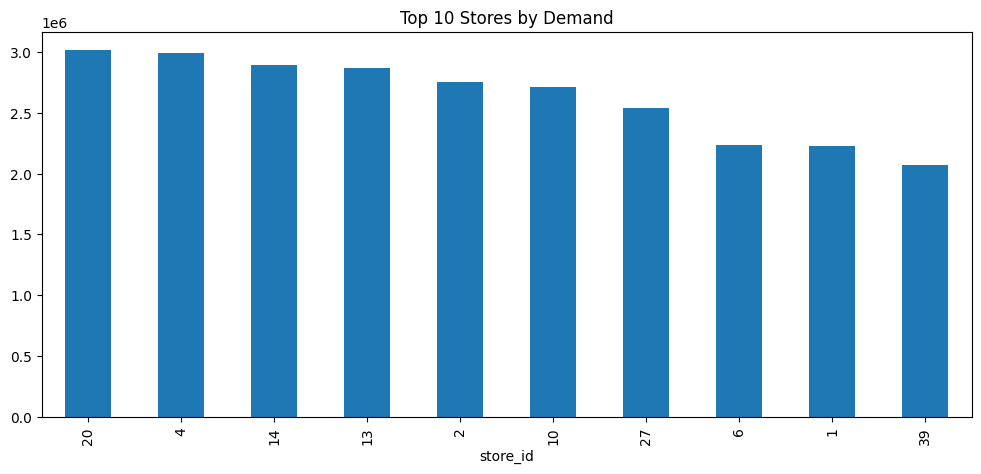

In [6]:
store_sales = df.groupby("store_id")["demand_units"].sum()

store_sales.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Stores by Demand")
plt.show()

In [7]:
sku_sales = (
    df.groupby("sku_id")["demand_units"]
    .sum()
    .sort_values(ascending=False)
)

sku_sales = sku_sales.reset_index()
sku_sales["cum_pct"] = (
    sku_sales["demand_units"].cumsum() /
    sku_sales["demand_units"].sum()
)

def classify_abc(x):
    if x <= 0.8:
        return "A"
    elif x <= 0.95:
        return "B"
    return "C"

sku_sales["abc_class"] = sku_sales["cum_pct"].apply(classify_abc)

sku_sales["abc_class"].value_counts()

abc_class
C    33
A    28
B    20
Name: count, dtype: int64